In [1]:
import os, glob, platform, importlib.metadata as metadata, warnings, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
warnings.filterwarnings("ignore")

RANDOM_STATE = 42
OUTPUT_DIR = "/content/day5_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Python:", platform.python_version())

Python: 3.13.15


In [2]:
def find_file(patterns):
    for p in patterns:
        if os.path.exists(p):
            return p
    for pattern in patterns:
        hits = glob.glob(pattern, recursive=True)
        if hits:
            return hits[0]
    return None

artifact_path = find_file([
    "/content/day4_pipeline.joblib",
    "/content/day4_outputs/day4_pipeline.joblib",
    "/content/drive/MyDrive/day4_pipeline.joblib",
    "/content/**/day4_pipeline.joblib"
])

print("Artifact:", artifact_path)
if artifact_path is None:
    raise FileNotFoundError("Upload day4_pipeline.joblib to Colab.")

Artifact: /content/day4_pipeline.joblib


In [3]:
# Compatibility module required to load the Day 4 artifact
feature_engineer_code = '''
import numpy as np
import pandas as pd

class FeatureEngineer:
    @staticmethod
    def add_engineered_features(frame: pd.DataFrame) -> pd.DataFrame:
        out = frame.copy()
        out["age_bucket"] = pd.cut(
            out["age"], bins=[0, 25, 35, 45, 55, 65, 120],
            labels=["<=25", "26-35", "36-45", "46-55", "56-65", "65+"]
        ).astype(str)
        out["hours_bucket"] = pd.cut(
            out["hours-per-week"], bins=[0, 20, 35, 40, 50, 100],
            labels=["<=20", "21-35", "36-40", "41-50", "50+"]
        ).astype(str)
        out["has_capital_gain"] = (out["capital-gain"] > 0).astype(int)
        out["log_capital_gain"] = np.log1p(out["capital-gain"])
        out["higher_education"] = (out["education-num"] >= 13).astype(int)
        out["edu_hours_interaction"] = out["education-num"] * out["hours-per-week"]
        return out
'''

module_path = "/content/feature_engineer.py"
with open(module_path, "w", encoding="utf-8") as f:
    f.write(feature_engineer_code)

import sys
if "/content" not in sys.path:
    sys.path.insert(0, "/content")

import feature_engineer
print("Compatibility module loaded:", feature_engineer.__file__)


Compatibility module loaded: /content/feature_engineer.py


In [4]:
artifact = joblib.load(artifact_path)

if hasattr(artifact, "predict_proba") or hasattr(artifact, "predict"):
    final_pipeline = artifact
    threshold = 0.5
    artifact_metadata = {}
elif isinstance(artifact, dict):
    final_pipeline = next(
        (artifact[k] for k in ["pipeline","model","final_pipeline","calibrated_pipeline"]
         if k in artifact and artifact[k] is not None),
        None
    )
    threshold = float(next(
        (artifact[k] for k in ["threshold","selected_threshold","classification_threshold"]
         if k in artifact), 0.5
    ))
    artifact_metadata = artifact.get("metadata", {})
else:
    raise TypeError("Unsupported Day 4 artifact format.")

if final_pipeline is None:
    raise ValueError("No fitted pipeline/model found in the Day 4 artifact.")

print("Loaded:", type(final_pipeline).__name__)
print("Threshold:", threshold)
print("Metadata keys:", list(artifact_metadata.keys()) if isinstance(artifact_metadata, dict) else [])

Loaded: CalibratedClassifierCV
Threshold: 0.42500000000000004
Metadata keys: []


In [5]:
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split

# Same Adult Census dataset source used in Days 3 and 4.
adult = fetch_openml('adult', version=2, as_frame=True)
df = adult.frame.copy()

target_col = 'class' if 'class' in df.columns else 'income'
df[target_col] = df[target_col].astype(str).str.strip()
df['target'] = (df[target_col] == '>50K').astype(int)
df = df.replace(r'^\s*\?\s*$', np.nan, regex=True)

feature_cols = [c for c in df.columns if c not in [target_col, 'target']]
X = df[feature_cols]
y = df['target']

X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)
X_train, X_dev, y_train, y_dev = train_test_split(
    X_trainval, y_trainval, test_size=0.125, stratify=y_trainval, random_state=RANDOM_STATE
)

print("Train:", X_train.shape, " Dev:", X_dev.shape, " Test (hold-out):", X_test.shape)
print("Positive rates:", round(y_train.mean(), 4), round(y_dev.mean(), 4), round(y_test.mean(), 4))
assert set(X_train.index).isdisjoint(X_dev.index)
assert set(X_train.index).isdisjoint(X_test.index)
assert set(X_dev.index).isdisjoint(X_test.index)
print("Leakage check: PASS — all three partitions are disjoint.")

Train: (34188, 14)  Dev: (4885, 14)  Test (hold-out): (9769, 14)
Positive rates: 0.2393 0.2393 0.2393
Leakage check: PASS — all three partitions are disjoint.


# Task 1: Final Model Validation

In [6]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, brier_score_loss,
    confusion_matrix, roc_curve, precision_recall_curve
)

if hasattr(final_pipeline, "predict_proba"):
    test_prob = final_pipeline.predict_proba(X_test)[:, 1]
elif hasattr(final_pipeline, "decision_function"):
    s = final_pipeline.decision_function(X_test)
    test_prob = 1 / (1 + np.exp(-s))
else:
    raise AttributeError("Saved artifact cannot produce probabilities.")

test_pred = (test_prob >= threshold).astype(int)

final_metrics = {
    "Accuracy": accuracy_score(y_test, test_pred),
    "Precision": precision_score(y_test, test_pred, zero_division=0),
    "Recall": recall_score(y_test, test_pred, zero_division=0),
    "F1": f1_score(y_test, test_pred, zero_division=0),
    "ROC_AUC": roc_auc_score(y_test, test_prob),
    "PR_AUC": average_precision_score(y_test, test_prob),
    "Brier": brier_score_loss(y_test, test_prob)
}
metrics_df = pd.DataFrame([final_metrics])
display(metrics_df.round(6))
metrics_df.to_csv(os.path.join(OUTPUT_DIR, "final_metrics.csv"), index=False)

cm = confusion_matrix(y_test, test_pred)
tn, fp, fn, tp = cm.ravel()
print(f"TN={tn}, FP={fp}, FN={fn}, TP={tp}")

,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC,Brier
0,0.859351,0.763676,0.597092,0.670187,0.910646,0.793375,0.09949


TN=6999, FP=432, FN=942, TP=1396


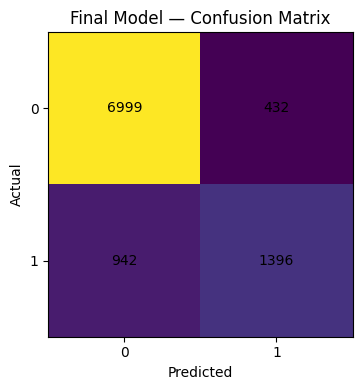

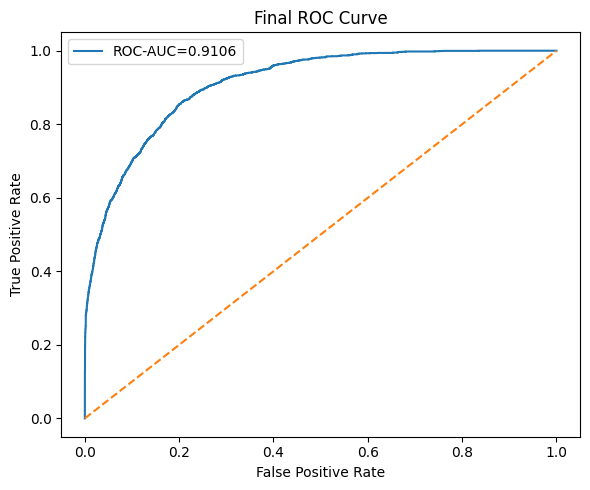

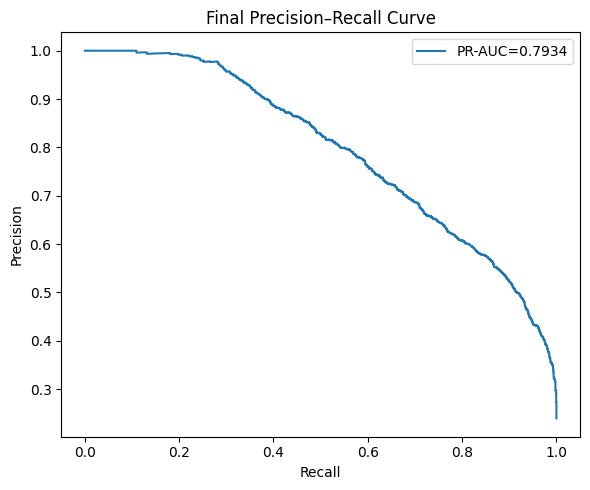

In [7]:
# Final confusion matrix
fig, ax = plt.subplots(figsize=(5,4))
ax.imshow(cm)
ax.set_title("Final Model — Confusion Matrix")
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_xticks([0,1]); ax.set_yticks([0,1])
for (i,j), v in np.ndenumerate(cm):
    ax.text(j, i, str(v), ha="center", va="center")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "confusion_matrix.png"), dpi=180, bbox_inches="tight")
plt.show()

# ROC
fpr, tpr, _ = roc_curve(y_test, test_prob)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"ROC-AUC={final_metrics['ROC_AUC']:.4f}")
plt.plot([0,1],[0,1],"--")
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("Final ROC Curve"); plt.legend(); plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "roc_curve.png"), dpi=180, bbox_inches="tight")
plt.show()

# PR
prec, rec, _ = precision_recall_curve(y_test, test_prob)
plt.figure(figsize=(6,5))
plt.plot(rec, prec, label=f"PR-AUC={final_metrics['PR_AUC']:.4f}")
plt.xlabel("Recall"); plt.ylabel("Precision")
plt.title("Final Precision–Recall Curve"); plt.legend(); plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "pr_curve.png"), dpi=180, bbox_inches="tight")
plt.show()

In [8]:
# Shortlisted-model comparison from Day 4 metadata, when available.
shortlisted = None
if isinstance(artifact_metadata, dict):
    shortlisted = artifact_metadata.get("shortlisted_models", artifact_metadata.get("model_comparison"))

if shortlisted is not None:
    shortlist_df = pd.DataFrame(shortlisted)
    if not shortlist_df.empty:
        display(shortlist_df)
        shortlist_df.to_csv(os.path.join(OUTPUT_DIR, "shortlisted_models.csv"), index=False)
else:
    print("No shortlisted-model table was embedded in the Day 4 artifact; no values are fabricated.")

No shortlisted-model table was embedded in the Day 4 artifact; no values are fabricated.


# Task 2: Model Behavior & Error Analysis

In [9]:
error_df = X_test.copy()
error_df["actual"] = y_test.to_numpy()
error_df["probability"] = test_prob
error_df["prediction"] = test_pred
error_df["error_type"] = np.select(
    [(error_df.actual==0)&(error_df.prediction==1),
     (error_df.actual==1)&(error_df.prediction==0)],
    ["False Positive","False Negative"],
    default="Correct"
)

display(error_df["error_type"].value_counts().to_frame("Count"))

print("Highest-confidence false positives:")
display(error_df[error_df.error_type=="False Positive"]
        .sort_values("probability", ascending=False).head(10))

print("Highest-confidence false negatives:")
display(error_df[error_df.error_type=="False Negative"]
        .sort_values("probability", ascending=True).head(10))

,Count
error_type,
Correct,8395
False Negative,942
False Positive,432


Highest-confidence false positives:


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,actual,probability,prediction,error_type
23260,63,Private,108097,Some-college,10,Married-civ-spouse,Craft-repair,Husband,White,Male,10566,0,45,United-States,0,0.971608,1,False Positive
4143,64,Private,159715,HS-grad,9,Married-civ-spouse,Transport-moving,Husband,White,Male,10566,0,40,United-States,0,0.967383,1,False Positive
18481,65,Private,90377,Assoc-voc,11,Married-civ-spouse,Farming-fishing,Husband,White,Male,6767,0,60,United-States,0,0.944308,1,False Positive
13831,67,Private,249043,Some-college,10,Married-civ-spouse,Sales,Husband,White,Male,6767,0,40,United-States,0,0.932267,1,False Positive
37919,45,Private,357540,Bachelors,13,Married-civ-spouse,Sales,Husband,White,Male,0,2002,55,United-States,0,0.924409,1,False Positive
34341,55,Local-gov,133201,Masters,14,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,50,United-States,0,0.911689,1,False Positive
30182,55,Self-emp-inc,222615,Masters,14,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,60,United-States,0,0.906075,1,False Positive
2247,55,Self-emp-inc,304695,Prof-school,15,Married-civ-spouse,Prof-specialty,Husband,White,Male,0,0,55,United-States,0,0.897810,1,False Positive
9847,35,Private,103323,Masters,14,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,45,United-States,0,0.891781,1,False Positive
3048,43,Federal-gov,190020,Prof-school,15,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,60,United-States,0,0.886682,1,False Positive


Highest-confidence false negatives:


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,actual,probability,prediction,error_type
48495,22,Local-gov,164775,5th-6th,3,Never-married,Handlers-cleaners,Other-relative,White,Male,0,0,40,Guatemala,1,0.028915,0,False Negative
36372,27,State-gov,23740,HS-grad,9,Never-married,Transport-moving,Not-in-family,Amer-Indian-Eskimo,Male,0,0,38,United-States,1,0.031894,0,False Negative
28811,39,Private,192251,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Female,0,0,40,United-States,1,0.032322,0,False Negative
25178,29,Private,137618,Some-college,10,Never-married,Other-service,Not-in-family,White,Female,0,0,41,United-States,1,0.032659,0,False Negative
10119,27,Private,98769,Assoc-voc,11,Never-married,Craft-repair,Unmarried,White,Male,0,0,40,United-States,1,0.032752,0,False Negative
47793,27,Private,147340,HS-grad,9,Never-married,Other-service,Not-in-family,White,Female,0,0,50,United-States,1,0.035456,0,False Negative
11144,28,Private,103432,HS-grad,9,Never-married,Transport-moving,Own-child,White,Male,0,0,45,Portugal,1,0.035506,0,False Negative
45466,48,Private,198000,Some-college,10,Never-married,Craft-repair,Unmarried,White,Female,0,0,38,United-States,1,0.035840,0,False Negative
22200,57,Private,365683,HS-grad,9,Divorced,Machine-op-inspct,Not-in-family,White,Female,0,0,40,United-States,1,0.036124,0,False Negative
11757,66,Self-emp-not-inc,58326,11th,7,Divorced,Other-service,Not-in-family,White,Female,0,0,40,United-States,1,0.036133,0,False Negative


In [10]:
# Subgroup analysis for important categorical/numeric fields.
subgroups = []
for col in ["sex","race","education","workclass","marital-status","occupation","age","hours-per-week"]:
    if col not in error_df.columns:
        continue
    for group, g in error_df.assign(_group=error_df[col].astype(str)).groupby("_group"):
        if len(g) < 30:
            continue
        subgroups.append({
            "Feature": col, "Group": group, "N": len(g),
            "Precision": precision_score(g.actual,g.prediction,zero_division=0),
            "Recall": recall_score(g.actual,g.prediction,zero_division=0),
            "F1": f1_score(g.actual,g.prediction,zero_division=0)
        })

subgroup_df = pd.DataFrame(subgroups)
if not subgroup_df.empty:
    display(subgroup_df.sort_values(["Feature","F1"]))
    subgroup_df.to_csv(os.path.join(OUTPUT_DIR,"subgroup_analysis.csv"),index=False)
else:
    print("No subgroup table could be produced.")

,Feature,Group,N,Precision,Recall,F1
49,age,17,99,0.000000,0.000000,0.000000
50,age,18,176,0.000000,0.000000,0.000000
51,age,19,224,0.000000,0.000000,0.000000
52,age,20,216,0.000000,0.000000,0.000000
53,age,21,226,0.000000,0.000000,0.000000
...,...,...,...,...,...,...
24,workclass,Private,6800,0.772477,0.565480,0.652966
26,workclass,Self-emp-not-inc,799,0.694581,0.629464,0.660422
27,workclass,State-gov,403,0.776596,0.657658,0.712195
23,workclass,Local-gov,584,0.769737,0.664773,0.713415


# Task3: Feature & Model Interpretation

In [11]:
from sklearn.compose import ColumnTransformer

def get_estimator(obj):
    if hasattr(obj, "steps"):
        for _, step in reversed(obj.steps):
            if hasattr(step, "feature_importances_") or hasattr(step, "coef_"):
                return step
        return obj.steps[-1][1]
    if hasattr(obj, "calibrated_classifiers_") and obj.calibrated_classifiers_:
        cc = obj.calibrated_classifiers_[0]
        return getattr(cc, "estimator", getattr(cc, "base_estimator", obj))
    return obj

estimator = get_estimator(final_pipeline)
print("Estimator:", type(estimator).__name__)

feature_names = None
if hasattr(final_pipeline, "named_steps"):
    for step in final_pipeline.named_steps.values():
        if isinstance(step, ColumnTransformer):
            try:
                feature_names = np.asarray(step.get_feature_names_out())
            except Exception:
                pass
if isinstance(final_pipeline, ColumnTransformer):
    try:
        feature_names = np.asarray(final_pipeline.get_feature_names_out())
    except Exception:
        pass

Estimator: Pipeline


In [12]:
importance_df = None

if hasattr(estimator, "feature_importances_"):
    vals = np.asarray(estimator.feature_importances_).ravel()
    names = feature_names if feature_names is not None and len(feature_names)==len(vals) else [f"feature_{i}" for i in range(len(vals))]
    importance_df = pd.DataFrame({"Feature":names,"Importance":vals}).sort_values("Importance",ascending=False).head(20)

elif hasattr(estimator, "coef_"):
    vals = np.asarray(estimator.coef_).ravel()
    names = feature_names if feature_names is not None and len(feature_names)==len(vals) else [f"feature_{i}" for i in range(len(vals))]
    importance_df = pd.DataFrame({
        "Feature":names,"Coefficient":vals,"Absolute_Importance":np.abs(vals)
    }).sort_values("Absolute_Importance",ascending=False).head(20)

if importance_df is not None and not importance_df.empty:
    display(importance_df)
    importance_df.to_csv(os.path.join(OUTPUT_DIR,"feature_importance.csv"),index=False)

    value_col = "Importance" if "Importance" in importance_df else "Coefficient"
    plot_df = importance_df.sort_values(value_col)
    plt.figure(figsize=(9,6))
    plt.barh(plot_df["Feature"].astype(str), plot_df[value_col])
    plt.xlabel(value_col); plt.title("Top Model Features"); plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR,"feature_importance.png"),dpi=180,bbox_inches="tight")
    plt.show()
else:
    print("No supported coef_/feature_importances_ interface was found. No interpretation was fabricated.")

No supported coef_/feature_importances_ interface was found. No interpretation was fabricated.


# Task 4: Production-Ready Inference

In [13]:
def run_inference(artifact_or_pipeline, new_data, classification_threshold=None):
    if isinstance(artifact_or_pipeline, dict):
        pipe = next((artifact_or_pipeline[k] for k in
                     ["pipeline","model","final_pipeline","calibrated_pipeline"]
                     if k in artifact_or_pipeline and artifact_or_pipeline[k] is not None), None)
        default_t = float(next((artifact_or_pipeline[k] for k in
                                ["threshold","selected_threshold","classification_threshold"]
                                if k in artifact_or_pipeline), 0.5))
    else:
        pipe = artifact_or_pipeline
        default_t = 0.5

    if classification_threshold is None:
        classification_threshold = default_t

    probability = pipe.predict_proba(new_data)[:,1]
    prediction = (probability >= float(classification_threshold)).astype(int)

    return pd.DataFrame({
        "probability_positive": probability,
        "prediction": prediction
    })

# 10 unseen examples from the untouched test set.
inference_examples = X_test.sample(min(10,len(X_test)), random_state=RANDOM_STATE)
inference_results = run_inference(artifact, inference_examples, threshold)
display(inference_results)
assert len(inference_results) == len(inference_examples)
print("Inference test: PASS")

,probability_positive,prediction
0,0.038434,0
1,0.044800,0
2,0.078206,0
3,0.029020,0
4,0.028990,0
5,0.138463,0
6,0.029261,0
7,0.936708,1
8,0.247950,0
9,0.788985,1


Inference test: PASS


In [14]:
inference_code = '''import joblib
import pandas as pd

artifact = joblib.load("day4_pipeline.joblib")
pipeline = artifact["pipeline"] if isinstance(artifact, dict) else artifact
threshold = artifact.get("threshold", 0.5) if isinstance(artifact, dict) else 0.5

# Example deployment input: replace this with a new raw record having the same columns.
new_data = X_test.iloc[[0]].copy()

probability = pipeline.predict_proba(new_data)[:, 1]
prediction = (probability >= threshold).astype(int)

print("Probability:", probability[0])
print("Prediction:", prediction[0])
'''
with open(os.path.join(OUTPUT_DIR,"inference_example.py"),"w",encoding="utf-8") as f:
    f.write(inference_code)
print(inference_code)

import joblib
import pandas as pd

artifact = joblib.load("day4_pipeline.joblib")
pipeline = artifact["pipeline"] if isinstance(artifact, dict) else artifact
threshold = artifact.get("threshold", 0.5) if isinstance(artifact, dict) else 0.5

# Example deployment input: replace this with a new raw record having the same columns.
new_data = X_test.iloc[[0]].copy()

probability = pipeline.predict_proba(new_data)[:, 1]
prediction = (probability >= threshold).astype(int)

print("Probability:", probability[0])
print("Prediction:", prediction[0])

